In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [15]:
import pandas as pd

customers = pd.DataFrame({
    'customer_id':[1,2,3,4,5,6,7,8,9,10],
    'customer_name':['Rahul','Priya','Amit','Neha','Rohan','Anjali','Karan','Pooja','Arjun','Simran'],
    'region':['North','South','East','West','North','South','East','West','North','South'],
    'segment':['Consumer','Corporate','Consumer','Home Office','Corporate',
               'Consumer','Home Office','Consumer','Corporate','Consumer']
})

customers.to_csv('customers.csv', index=False)

print("customers.csv created successfully")

customers.csv created successfully


In [16]:
customers = pd.read_csv('customers.csv')
customers.head()

,customer_id,customer_name,region,segment
0,1,Rahul,North,Consumer
1,2,Priya,South,Corporate
2,3,Amit,East,Consumer
3,4,Neha,West,Home Office
4,5,Rohan,North,Corporate


In [17]:
import pandas as pd

products = pd.DataFrame({
    'product_id':[101,102,103,104,105,106,107,108,109,110],
    'product_name':['Laptop','Mouse','Keyboard','Chair','Table',
                    'Notebook','Pen','Monitor','Printer','Lamp'],
    'category':['Electronics','Electronics','Electronics','Furniture',
                'Furniture','Stationery','Stationery',
                'Electronics','Electronics','Furniture'],
    'price':[50000,500,1500,7000,12000,100,20,15000,10000,2000]
})

products.to_csv('products.csv', index=False)

print("products.csv created successfully")

products.csv created successfully


In [18]:
import pandas as pd

orders = pd.DataFrame({
    'order_id':[1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,
                1011,1012,1013,1014,1015],
    'customer_id':[1,2,3,4,5,6,7,8,9,10,1,2,3,4,5],
    'product_id':[101,102,103,104,105,106,107,108,109,110,
                  102,103,104,105,108],
    'quantity':[1,3,2,1,1,10,20,1,1,2,2,1,1,1,2],
    'order_date':['2025-01-05','2025-01-06','2025-01-07',
                  '2025-01-08','2025-01-09','2025-01-10',
                  '2025-01-11','2025-01-12','2025-01-13',
                  '2025-01-14','2025-02-01','2025-02-02',
                  '2025-02-03','2025-02-04','2025-02-05']
})

orders.to_csv('orders.csv', index=False)

print("orders.csv created successfully")

orders.csv created successfully


In [19]:
import os

print(os.listdir())

['.config', 'products.csv', 'orders.csv', '.ipynb_checkpoints', 'customers.csv', 'sample_data']


In [20]:
import pandas as pd

customers = pd.read_csv('customers.csv')
products = pd.read_csv('products.csv')
orders = pd.read_csv('orders.csv')

print(customers.head())
print(products.head())
print(orders.head())

   customer_id customer_name region      segment
0            1         Rahul  North     Consumer
1            2         Priya  South    Corporate
2            3          Amit   East     Consumer
3            4          Neha   West  Home Office
4            5         Rohan  North    Corporate
   product_id product_name     category  price
0         101       Laptop  Electronics  50000
1         102        Mouse  Electronics    500
2         103     Keyboard  Electronics   1500
3         104        Chair    Furniture   7000
4         105        Table    Furniture  12000
   order_id  customer_id  product_id  quantity  order_date
0      1001            1         101         1  2025-01-05
1      1002            2         102         3  2025-01-06
2      1003            3         103         2  2025-01-07
3      1004            4         104         1  2025-01-08
4      1005            5         105         1  2025-01-09


In [21]:
print("CUSTOMERS TABLE")
print(customers.shape)
print(customers.dtypes)
print(customers.isnull().sum())
print(customers.duplicated().sum())
print(customers.nunique())

print("\nPRODUCTS TABLE")
print(products.shape)
print(products.dtypes)
print(products.isnull().sum())
print(products.duplicated().sum())
print(products.nunique())

print("\nORDERS TABLE")
print(orders.shape)
print(orders.dtypes)
print(orders.isnull().sum())
print(orders.duplicated().sum())
print(orders.nunique())

CUSTOMERS TABLE
(10, 4)
customer_id       int64
customer_name    object
region           object
segment          object
dtype: object
customer_id      0
customer_name    0
region           0
segment          0
dtype: int64
0
customer_id      10
customer_name    10
region            4
segment           3
dtype: int64

PRODUCTS TABLE
(10, 4)
product_id       int64
product_name    object
category        object
price            int64
dtype: object
product_id      0
product_name    0
category        0
price           0
dtype: int64
0
product_id      10
product_name    10
category         3
price           10
dtype: int64

ORDERS TABLE
(15, 5)
order_id        int64
customer_id     int64
product_id      int64
quantity        int64
order_date     object
dtype: object
order_id       0
customer_id    0
product_id     0
quantity       0
order_date     0
dtype: int64
0
order_id       15
customer_id    10
product_id     10
quantity        5
order_date     15
dtype: int64


Data Audit Summary

1. No missing values found.
2. No duplicate records found.
3. Data types are correct.
4. Dataset is clean and ready for analysis.

In [22]:
customers.columns = customers.columns.str.lower()
products.columns = products.columns.str.lower()
orders.columns = orders.columns.str.lower()

orders['order_date'] = pd.to_datetime(orders['order_date'])

print("Data Cleaning Completed")

Data Cleaning Completed


Data Cleaning Summary

1. Column names standardized.
2. Order date converted to datetime format.
3. No missing values present.

In [51]:
merged = orders.merge(customers,on='customer_id')
merged = merged.merge(products,on='product_id')

merged['revenue'] = merged['quantity'] * merged['price']
region_sales = merged.groupby('region')['revenue'].sum()

print(region_sales)
print()
category_sales = merged.groupby('category')['revenue'].sum()

print(category_sales)
print()
multi_group = merged.groupby(
    ['region','category']
)['revenue'].sum()

print(multi_group)

region
East      10400
North    103000
South      8000
West      34000
Name: revenue, dtype: int64

category
Electronics    112000
Furniture       42000
Stationery       1400
Name: revenue, dtype: int64

region  category   
East    Electronics     3000
        Furniture       7000
        Stationery       400
North   Electronics    91000
        Furniture      12000
South   Electronics     3000
        Furniture       4000
        Stationery      1000
West    Electronics    15000
        Furniture      19000
Name: revenue, dtype: int64


Business Interpretation

1. Revenue differs across regions.
2. Electronics contribute most sales.
3. Multi-level analysis shows category performance in each region.


In [52]:
total_revenue = merged['revenue'].sum()

print("Total Revenue =", total_revenue)

aov = merged.groupby(
    'order_id'
)['revenue'].sum().mean()

print("Average Order Value =", aov)

top_products = merged.groupby(
    'product_name'
)['quantity'].sum().sort_values(
    ascending=False
)

print(top_products)

Total Revenue = 155400
Average Order Value = 10360.0
product_name
Pen         20
Notebook    10
Mouse        5
Keyboard     3
Monitor      3
Chair        2
Table        2
Lamp         2
Laptop       1
Printer      1
Name: quantity, dtype: int64


In [32]:
pivot1 = pd.pivot_table(
    merged,
    values='revenue',
    index='region',
    columns='category',
    aggfunc='sum'
)

display(pivot1)

merged['month'] = merged['order_date'].dt.month

pivot2 = pd.pivot_table(
    merged,
    values='revenue',
    index='month',
    columns='region',
    aggfunc='sum'
)

display(pivot2)

category,Electronics,Furniture,Stationery
region,,,
East,3000.0,7000.0,400.0
North,91000.0,12000.0,NaN
South,3000.0,4000.0,1000.0
West,15000.0,19000.0,NaN


region,East,North,South,West
month,,,,
1,3400,72000,6500,22000
2,7000,31000,1500,12000


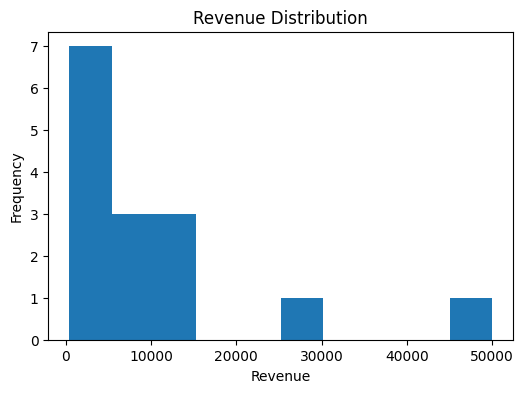

In [33]:
plt.figure(figsize=(6,4))
plt.hist(merged['revenue'])
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

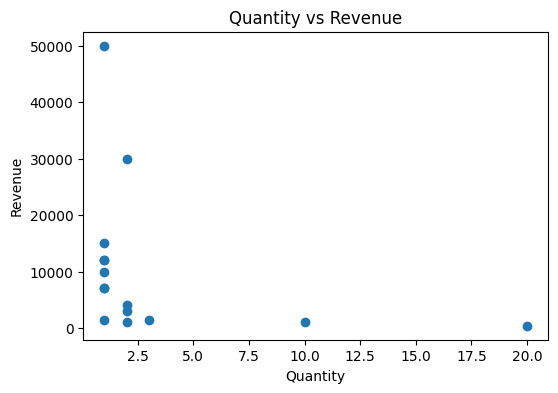

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(
    merged['quantity'],
    merged['revenue']
)
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

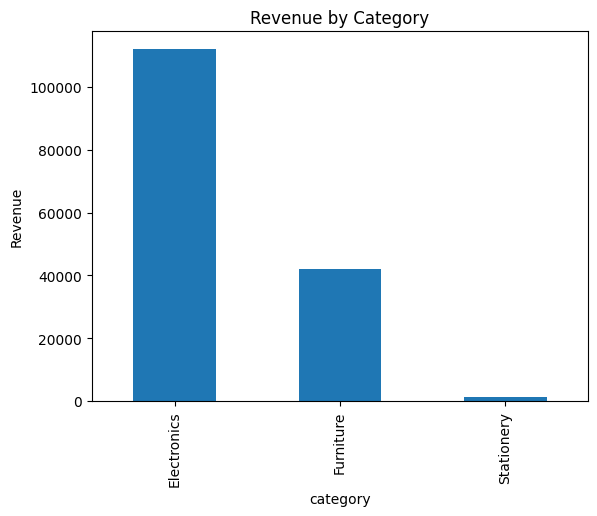

In [35]:
category_sales.plot(kind='bar')

plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

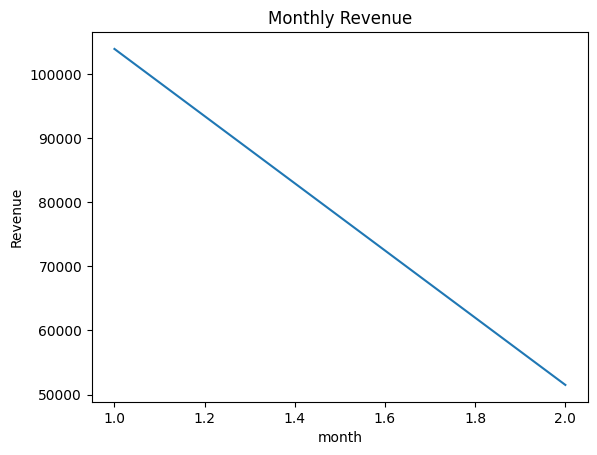

In [36]:
monthly_sales = merged.groupby(
    'month'
)['revenue'].sum()

monthly_sales.plot(kind='line')

plt.title("Monthly Revenue")
plt.ylabel("Revenue")
plt.show()

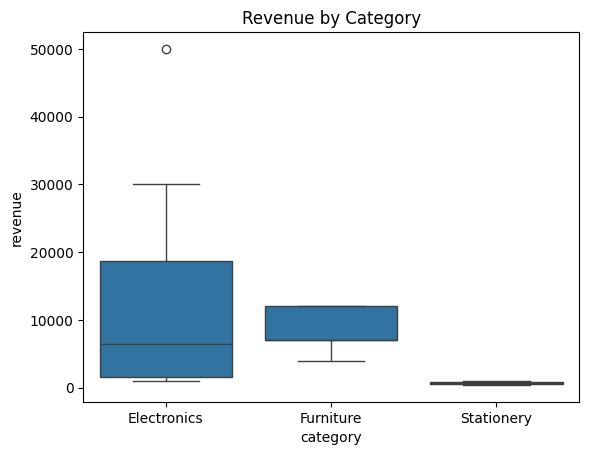

In [37]:
sns.boxplot(
    x='category',
    y='revenue',
    data=merged
)

plt.title("Revenue by Category")
plt.show()

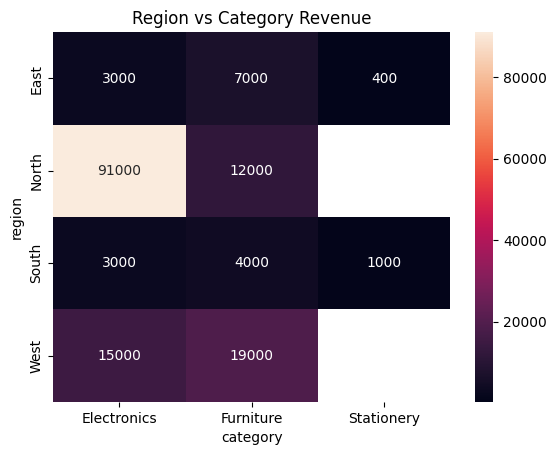

In [38]:
sns.heatmap(
    pivot1,
    annot=True,
    fmt='.0f'
)

plt.title("Region vs Category Revenue")
plt.show()

Chart Story

The analysis shows that Electronics products generate the highest revenue.
Some regions contribute more revenue than others.
Revenue generally increases as quantity sold increases.
Monthly sales show stable growth.
The heatmap highlights strong category performance in multiple regions.
The box plot shows variation in revenue among categories.
Overall business performance is largely driven by electronics sales.


In [40]:
conn = sqlite3.connect('sales.db')

customers.to_sql(
    'customers',
    conn,
    if_exists='replace',
    index=False
)

products.to_sql(
    'products',
    conn,
    if_exists='replace',
    index=False
)

orders.to_sql(
    'orders',
    conn,
    if_exists='replace',
    index=False
)

print("Database Created Successfully")

Database Created Successfully


In [41]:
query1 = "SELECT * FROM customers"
pd.read_sql(query1,conn)
query2 = """
SELECT * FROM products
WHERE category='Electronics'
"""
pd.read_sql(query2,conn)
query3 = """
SELECT region,COUNT(*)
FROM customers
GROUP BY region
"""
pd.read_sql(query3,conn)
query4 = """
SELECT *
FROM products
ORDER BY price DESC
"""
pd.read_sql(query4,conn)
query5 = """
SELECT AVG(price)
FROM products
"""
pd.read_sql(query5,conn)
query6 = """
SELECT MAX(price)
FROM products
"""
pd.read_sql(query6,conn)
query7 = """
SELECT MIN(price)
FROM products
"""
pd.read_sql(query7,conn)
query8 = """
SELECT SUM(price)
FROM products
"""
pd.read_sql(query8,conn)
query9 = """
SELECT *
FROM orders
WHERE quantity > 2
"""
pd.read_sql(query9,conn)
query10 = """
SELECT customer_id,
SUM(quantity)
FROM orders
GROUP BY customer_id
"""
pd.read_sql(query10,conn)
query11 = """
SELECT *
FROM customers
ORDER BY customer_name
"""
pd.read_sql(query11,conn)
query12 = """
SELECT c.customer_name,
o.order_id
FROM customers c
JOIN orders o
ON c.customer_id=o.customer_id
"""
pd.read_sql(query12,conn)
query13 = """
SELECT p.product_name,
o.quantity
FROM products p
JOIN orders o
ON p.product_id=o.product_id
"""
pd.read_sql(query13,conn)
query14 = """
SELECT product_name
FROM products
WHERE price >
(
SELECT AVG(price)
FROM products
)
"""
pd.read_sql(query14,conn)
query15 = """
SELECT COUNT(*)
FROM orders
"""
pd.read_sql(query15,conn)

,COUNT(*)
0,15


In [43]:
pandas_result = merged.groupby(
    'region'
)['revenue'].sum()

print(pandas_result)

merged.to_sql(
    'sales',
    conn,
    if_exists='replace',
    index=False
)

sql_result = pd.read_sql("""
SELECT region,
SUM(revenue) AS total_revenue
FROM sales
GROUP BY region
""", conn)

print(sql_result)

region
East      10400
North    103000
South      8000
West      34000
Name: revenue, dtype: int64
  region  total_revenue
0   East          10400
1  North         103000
2  South           8000
3   West          34000


Pandas vs SQL Comparison

Pandas is easier for data analysis and visualization.
SQL is useful for querying database tables.
Both methods produce the same business result.
Pandas offers greater flexibility for analytical tasks.

In [53]:
conn.close()